In [ ]:
import pandas as pd
import yfinance as yf 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

df  =  pd.read_csv('IBM_HR_dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv')
print("Датасет загружен.") 
# df 
df.info() 

Датасет загружен.


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [ ]:

# 1.Используя данный набор данных создайте новый, состоящий только из 
# тех строк, где значение в столбце Целевая.Цена выше 800000. Сохраните 
# его в отдельный csv файл. Но такого столбца нет в этом датасете, поэтому использую столбец MonthlyIncome

df = pd.read_csv('IBM_HR_dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv')
df_filtered = df[df['MonthlyIncome'] > 8000]
df_filtered.to_csv('hr_filtered.csv', index=False)

In [ ]:
# 2.Откройте данный файл и добавте в него новый столбец в котором 
# значения столбца Оценка риелтора увеличены на 2

df2 = pd.read_csv('hr_filtered.csv')
df2['JobSatisfactionPlusTwo'] = df2['JobSatisfaction'] + 2
df2.to_csv('hr_filtered.csv', index=False)

In [19]:
TICKERS = ['IBM', 'MSFT', 'GOOGL', 'AAPL', 'TSLA'] 
START_DATE = '2024-01-01' 
END_DATE = '2024-12-31' 
INTERVAL = '1d' 
WEIGHTS = np.array([1/5] * 5)  # равные доли

prices = yf.download( 
    tickers=TICKERS, 
    start=START_DATE, 
    end=END_DATE, 
    interval=INTERVAL 
)['Close']

print("\nИнформация о датасете:") 
# prices.info()
# prices.TSLA.plot() 

returns = prices.pct_change().dropna()
port_ret_series = (returns * WEIGHTS).sum(axis=1) 
print("Ежедневная доходность портфеля (первые 5 дней):") 
port_ret_series.head()

corr_matrix = returns.corr().round(3) 
print('\nКорреляционная матрица доходностей:') 
corr_matrix

[*********************100%***********************]  5 of 5 completed


Информация о датасете:
Ежедневная доходность портфеля (первые 5 дней):

Корреляционная матрица доходностей:


Ticker,AAPL,GOOGL,IBM,MSFT,TSLA
Ticker,,,,,
AAPL,1.000,0.359,0.119,0.470,0.328
GOOGL,0.359,1.000,0.100,0.572,0.251
IBM,0.119,0.100,1.000,0.292,-0.028
MSFT,0.470,0.572,0.292,1.000,0.300
TSLA,0.328,0.251,-0.028,0.300,1.000


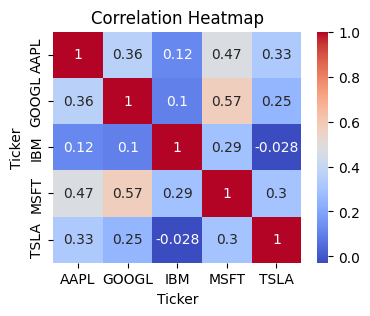

In [14]:
plt.figure(figsize=(4, 3)) 
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm') 
plt.title('Correlation Heatmap') 
plt.show() 

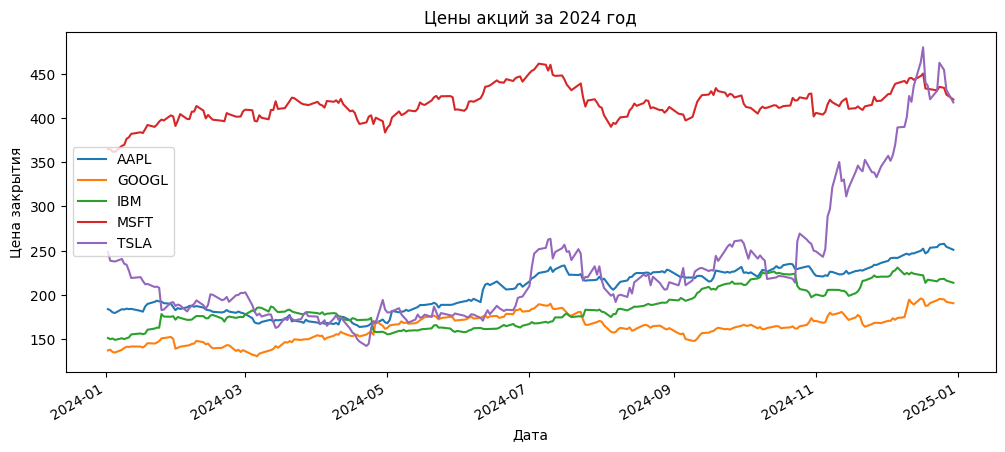

In [ ]:
# 1.Нарисовать графики остальных акций

prices.plot(figsize=(12, 5), title='Цены акций за 2024 год')
plt.xlabel('Дата')
plt.ylabel('Цена закрытия')
plt.legend()
plt.show()

In [ ]:
# 2.Вопрос посложнее - как посчитать доходность портфеля за год?

cumulative = (1 + port_ret_series).cumprod() 
annual_return = cumulative.iloc[-1] - 1
print(f"Доходность портфеля за год: {annual_return:.2%}")

Доходность портфеля за год: 44.68%


In [25]:
# 3.Добавьте в потрфель золото 'GLD' и поменяйте все доли на 1/6

TICKERS_NEW = ['IBM', 'MSFT', 'GOOGL', 'AAPL', 'TSLA', 'GLD']
WEIGHTS_NEW = np.array([1/6] * 6) 

prices_new = yf.download(
    tickers=TICKERS_NEW,
    start=START_DATE,
    end=END_DATE,
    interval=INTERVAL
)['Close']

returns_new = prices_new.pct_change().dropna()
port_ret_new = (returns_new * WEIGHTS_NEW).sum(axis=1)
cumulative_new = (1 + port_ret_new).cumprod()

[*********************100%***********************]  6 of 6 completed


In [21]:
annual_return_new = cumulative_new.iloc[-1] - 1
print(f"Доходность портфеля с золотом за год: {annual_return_new:.2%}")

Доходность портфеля с золотом за год: 41.97%


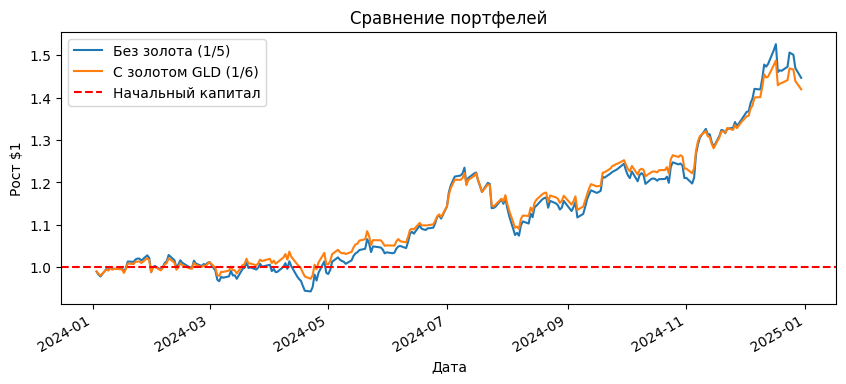

In [23]:
plt.figure(figsize=(10, 4))
cumulative.plot(label='Без золота (1/5)')
cumulative_new.plot(label='С золотом GLD (1/6)')
plt.title('Сравнение портфелей')
plt.ylabel('Рост $1')
plt.xlabel('Дата')
plt.axhline(y=1, color='red', linestyle='--', label='Начальный капитал')
plt.legend()
plt.show()

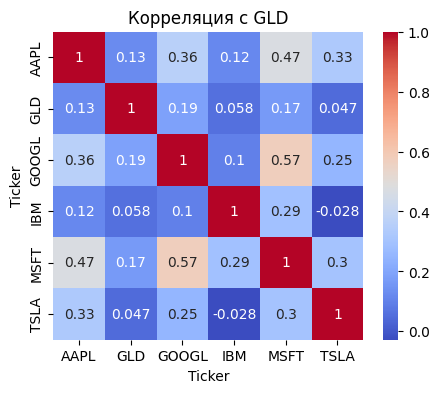

In [24]:
corr_new = returns_new.corr().round(3)
plt.figure(figsize=(5, 4))
sns.heatmap(corr_new, annot=True, cmap='coolwarm')
plt.title('Корреляция с GLD')
plt.show()